# k-Nearest Neighbors for Security Classification

**Goal:** understand distance, voting, scaling, model selection, and operational evaluation. We classify synthetic authentication sessions as routine or review-worthy.

> Labels are synthetic. A model score prioritizes human review; it does not establish that a user is malicious.

## 1. How KNN works

KNN stores the training set. For a query $x$, it computes a distance to each training example, selects the $k$ smallest distances, and predicts by majority (or distance-weighted) vote. Euclidean distance is

$$d(x,z)=\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}. $$

Training is cheap, prediction is comparatively expensive, and feature scale defines what ‘near’ means.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             precision_recall_curve, average_precision_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 207
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Compute neighbors by hand
This tiny example exposes the mechanics hidden by `KNeighborsClassifier`.

In [2]:
training_points = np.array([[1, 1], [2, 1], [2, 3], [6, 5], [7, 7], [8, 6]], dtype=float)
training_labels = np.array([0, 0, 0, 1, 1, 1])
query = np.array([5, 4], dtype=float)
distances = np.sqrt(((training_points - query) ** 2).sum(axis=1))
neighbor_order = np.argsort(distances)
k = 3
nearest = neighbor_order[:k]
manual_prediction = np.bincount(training_labels[nearest]).argmax()
pd.DataFrame({
    'x1': training_points[:, 0], 'x2': training_points[:, 1],
    'label': training_labels, 'distance_to_query': distances,
    'rank': np.argsort(neighbor_order) + 1,
}).sort_values('distance_to_query'), manual_prediction

(    x1   x2  label  distance_to_query  rank
 3  6.0  5.0      1           1.414214     1
 2  2.0  3.0      0           3.162278     2
 5  8.0  6.0      1           3.605551     3
 4  7.0  7.0      1           3.605551     4
 1  2.0  1.0      0           4.242641     5
 0  1.0  1.0      0           5.000000     6,
 np.int64(1))

## 3. Synthetic authentication sessions

Features are known at scoring time: failed attempts, hour-of-day deviation from the account's norm, request volume, and distinct source networks. The review label is imbalanced to resemble queue prioritization.

In [3]:
n = 900
failed_attempts = rng.poisson(1.2, n)
hour_deviation = np.clip(rng.gamma(2.0, 1.4, n), 0, 12)
request_count = rng.lognormal(4.0, 0.65, n).astype(int)
source_networks = np.clip(rng.poisson(1.5, n) + 1, 1, 12)
risk = (0.9 * failed_attempts + 0.55 * hour_deviation +
        0.012 * request_count + 0.7 * source_networks + rng.normal(0, 1.4, n))
review = (risk > np.quantile(risk, 0.82)).astype(int)
sessions = pd.DataFrame({
    'failed_attempts': failed_attempts,
    'hour_deviation': hour_deviation,
    'request_count': request_count,
    'source_networks': source_networks,
    'review': review,
})
print(sessions['review'].value_counts(normalize=True).rename('fraction'))
sessions.head()

review
0    0.82
1    0.18
Name: fraction, dtype: float64


,failed_attempts,hour_deviation,request_count,source_networks,review
0,0,0.305297,71,3,0
1,2,2.341977,32,6,1
2,3,5.034767,23,4,0
3,3,0.225404,107,2,0
4,2,1.674591,36,3,0


## 4. Split before preprocessing

Use training data to fit candidates, validation data to select $k$, and test data once for the final estimate. Stratification preserves the class ratio.

In [4]:
X = sessions.drop(columns='review')
y = sessions['review']
X_build, X_test, y_build, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_build, y_build, test_size=0.25, stratify=y_build, random_state=RANDOM_STATE
)
print('train / validation / test:', len(X_train), len(X_valid), len(X_test))

train / validation / test: 540 180 180


## 5. Why scaling changes neighbors
`request_count` spans hundreds while other features span roughly 0–12. Without scaling, it can dominate Euclidean distance merely because of its units.

In [5]:
unscaled = KNeighborsClassifier(n_neighbors=7).fit(X_train, y_train)
scaled = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
]).fit(X_train, y_train)
print('Validation average precision')
print('unscaled:', round(average_precision_score(y_valid, unscaled.predict_proba(X_valid)[:, 1]), 3))
print('scaled:  ', round(average_precision_score(y_valid, scaled.predict_proba(X_valid)[:, 1]), 3))

Validation average precision
unscaled: 0.42
scaled:   0.611


## 6. Select $k$ on validation data
Small $k$ yields flexible, noisy boundaries; large $k$ smooths boundaries and can miss local structure. Average precision is useful for an imbalanced review queue because it evaluates ranking quality.

{1: np.float64(0.321), 3: np.float64(0.504), 5: np.float64(0.604), 7: np.float64(0.637), 11: np.float64(0.692), 17: np.float64(0.723), 25: np.float64(0.735), 35: np.float64(0.737)}


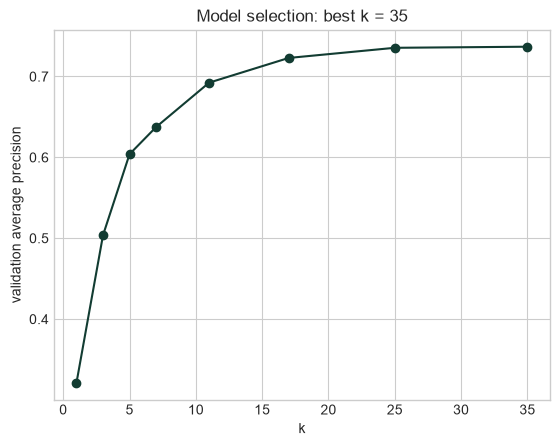

In [6]:
candidate_k = [1, 3, 5, 7, 11, 17, 25, 35]
scores = []
for k in candidate_k:
    candidate = Pipeline([
        ('scale', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance')),
    ])
    candidate.fit(X_train, y_train)
    score = average_precision_score(y_valid, candidate.predict_proba(X_valid)[:, 1])
    scores.append(score)
best_k = candidate_k[int(np.argmax(scores))]
plt.plot(candidate_k, scores, marker='o', color='#123c32')
plt.xlabel('k'); plt.ylabel('validation average precision'); plt.title(f'Model selection: best k = {best_k}');
print(dict(zip(candidate_k, np.round(scores, 3))))

## 7. Refit on build data; evaluate test data once
The default 0.5 threshold is only a starting point. In operations, choose a threshold from validation data based on analyst capacity and false-negative cost—not from the test set.

Test average precision: 0.711
              precision    recall  f1-score   support

     routine       0.85      0.99      0.92       148
      review       0.86      0.19      0.31        32

    accuracy                           0.85       180
   macro avg       0.85      0.59      0.61       180
weighted avg       0.85      0.85      0.81       180



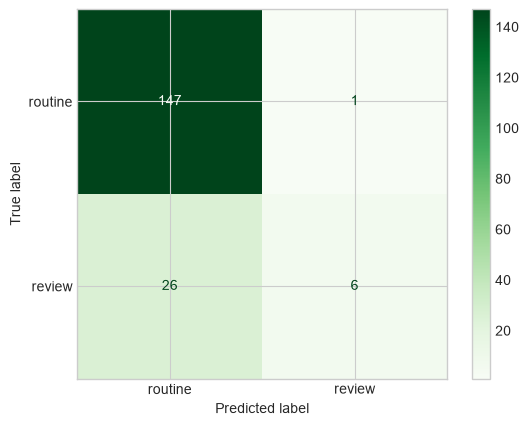

In [7]:
final_model = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights='distance')),
])
final_model.fit(X_build, y_build)
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
print('Test average precision:', round(average_precision_score(y_test, test_probability), 3))
print(classification_report(y_test, test_prediction, target_names=['routine', 'review']))
ConfusionMatrixDisplay.from_predictions(y_test, test_prediction, display_labels=['routine', 'review'], cmap='Greens');

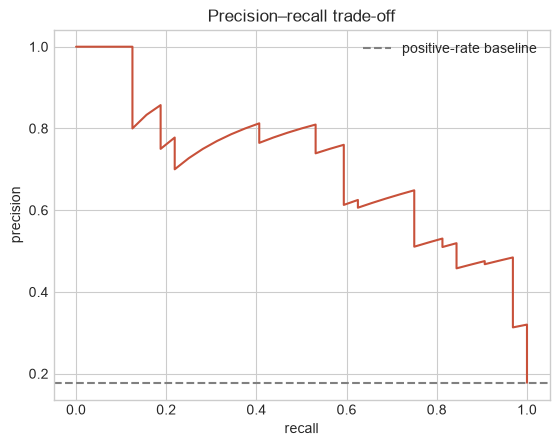

In [8]:
precision, recall, thresholds = precision_recall_curve(y_test, test_probability)
plt.plot(recall, precision, color='#c8513a')
plt.axhline(y_test.mean(), linestyle='--', color='gray', label='positive-rate baseline')
plt.xlabel('recall'); plt.ylabel('precision'); plt.title('Precision–recall trade-off'); plt.legend();

## 8. Visualize a two-feature boundary
This reduced model is for intuition. Real models use all four features, so this picture is not their full decision surface.

Text(0.5, 1.0, 'Local voting creates a nonlinear boundary')

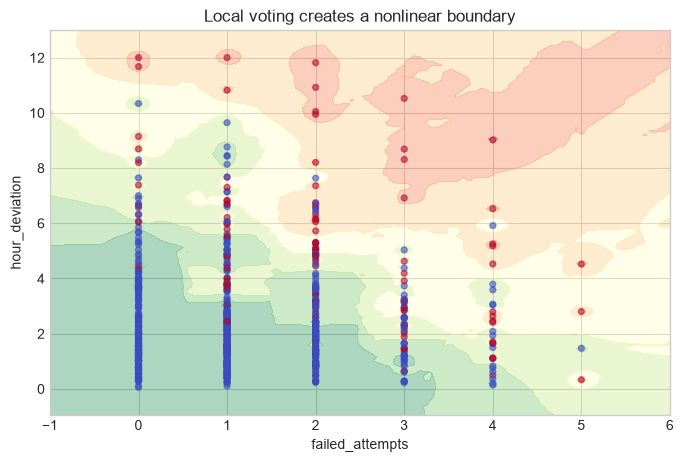

In [9]:
two_features = ['failed_attempts', 'hour_deviation']
visual_model = Pipeline([
    ('scale', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights='distance')),
]).fit(X_build[two_features], y_build)
fig, ax = plt.subplots(figsize=(8, 5))
DecisionBoundaryDisplay.from_estimator(visual_model, X_build[two_features], response_method='predict_proba',
                                       class_of_interest=1, alpha=0.35, cmap='RdYlGn_r', ax=ax)
ax.scatter(X_build['failed_attempts'], X_build['hour_deviation'], c=y_build, s=18, alpha=0.55, cmap='coolwarm')
ax.set_title('Local voting creates a nonlinear boundary')

## 9. Security interpretation and exercises

**Operational cautions:** KNN prediction cost grows with stored examples; irrelevant dimensions make distances less meaningful; duplicates can dominate a neighborhood; changing traffic patterns invalidate old neighbors; and probability estimates are discrete local vote fractions, not automatically calibrated risk.

**Try:**
1. Compare Euclidean (`p=2`) with Manhattan (`p=1`) distance.
2. Add an irrelevant random feature and measure the effect.
3. Choose a validation threshold that recalls at least 90% of review cases; report the resulting precision.
4. Replace the random split with a simulated time split and explain why deployment estimates may change.
5. Explain how an attacker generating many near-duplicate benign-looking points could influence a neighborhood and what data-quality controls would help.